In [ ]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing
import re
import string

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [ ]:
import pandas as pd

df = pd.read_parquet("hf://datasets/tdavidson/hate_speech_offensive/data/train-00000-of-00001.parquet")

In [ ]:
# First five rows
print(df.head())

# Shape
print("Dataset Shape:", df.shape)

# Column names
print(df.columns)

# Dataset information
print(df.info())

   count  hate_speech_count  offensive_language_count  neither_count  class  \
0      3                  0                         0              3      2   
1      3                  0                         3              0      1   
2      3                  0                         3              0      1   
3      3                  0                         2              1      1   
4      6                  0                         6              0      1   

                                               tweet  
0  !!! RT @mayasolovely: As a woman you shouldn't...  
1  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...  
2  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...  
3  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...  
4  !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...  
Dataset Shape: (24783, 6)
Index(['count', 'hate_speech_count', 'offensive_language_count',
       'neither_count', 'class', 'tweet'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
R

In [ ]:
print(df.isnull().sum())

count                       0
hate_speech_count           0
offensive_language_count    0
neither_count               0
class                       0
tweet                       0
dtype: int64


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


class
1    19190
2     4163
0     1430
Name: count, dtype: int64


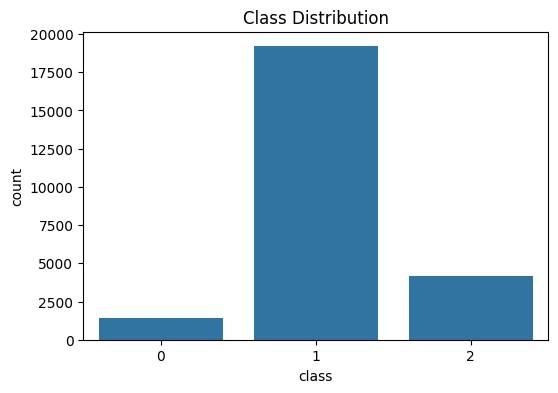

In [ ]:
print(df["class"].value_counts())


plt.figure(figsize=(6,4))
sns.countplot(x="class", data=df)
plt.title("Class Distribution")
plt.show()

In [ ]:
df["text_length"] = df["tweet"].apply(len)
print(df["text_length"].describe())

count    24783.000000
mean        85.436065
std         41.548238
min          5.000000
25%         52.000000
50%         81.000000
75%        119.000000
max        754.000000
Name: text_length, dtype: float64


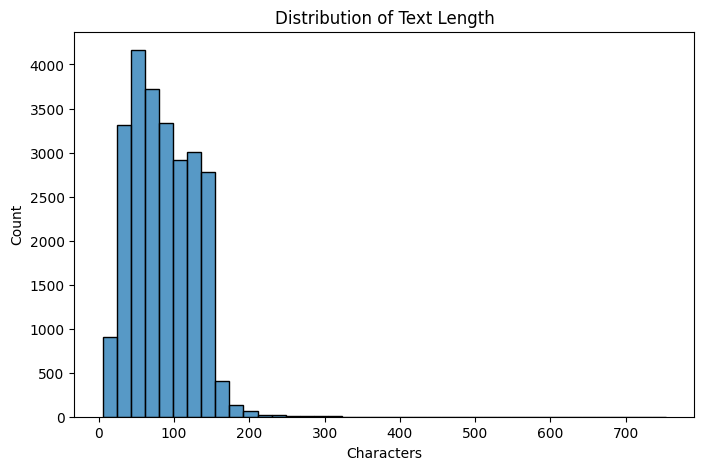

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["text_length"], bins=40)
plt.title("Distribution of Text Length")
plt.xlabel("Characters")
plt.show()

text cleaning

In [ ]:
def clean_text(text):

    # lowercase
    text = text.lower()

    # remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # remove mentions
    text = re.sub(r"@\w+", "", text)

    # remove hashtags symbol
    text = re.sub(r"#", "", text)

    # remove numbers
    text = re.sub(r"\d+", "", text)

    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [ ]:
df["clean_text"] = df["tweet"].apply(clean_text)

In [ ]:
df[["tweet","clean_text"]].head()

,tweet,clean_text
0,!!! RT @mayasolovely: As a woman you shouldn't...,rt as a woman you shouldnt complain about clea...
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,rt boy dats coldtyga dwn bad for cuffin dat ho...
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,rt dawg rt you ever fuck a bitch and she start...
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,rt she look like a tranny
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,rt the shit you hear about me might be true or...


In [ ]:
df = df[df["clean_text"] != ""]

In [ ]:
encoder = LabelEncoder()

df["class"] = encoder.fit_transform(df["class"])

In [ ]:
X = df["clean_text"]

y = df["class"]

Split Data

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [ ]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=1/3,
    random_state=42,
    stratify=y_temp
)

In [ ]:
print("Training:", len(X_train))
print("Validation:", len(X_val))
print("Testing:", len(X_test))

Training: 17346
Validation: 4956
Testing: 2479


In [ ]:
train_df = pd.DataFrame({
    "text": X_train,
    "label": y_train
})

val_df = pd.DataFrame({
    "text": X_val,
    "label": y_val
})

test_df = pd.DataFrame({
    "text": X_test,
    "label": y_test
})

In [ ]:
train_df.to_csv("train.csv", index=False)
val_df.to_csv("validation.csv", index=False)
test_df.to_csv("test.csv", index=False)

In [ ]:
print(y_train.value_counts())

print(y_val.value_counts())

print(y_test.value_counts())

class
1    13432
2     2913
0     1001
Name: count, dtype: int64
class
1    3837
2     833
0     286
Name: count, dtype: int64
class
1    1920
2     416
0     143
Name: count, dtype: int64


In [ ]:
print(df.columns)
print(df.head())

Index(['count', 'hate_speech_count', 'offensive_language_count',
       'neither_count', 'class', 'tweet', 'text_length', 'clean_text'],
      dtype='object')
   count  hate_speech_count  offensive_language_count  neither_count  class  \
0      3                  0                         0              3      2   
1      3                  0                         3              0      1   
2      3                  0                         3              0      1   
3      3                  0                         2              1      1   
4      6                  0                         6              0      1   

                                               tweet  text_length  \
0  !!! RT @mayasolovely: As a woman you shouldn't...          140   
1  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...           85   
2  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...          120   
3  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...           62   
4  !!!!!!!!!!!!! RT @

Train Model

In [ ]:
!pip install transformers datasets accelerate evaluate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00


In [ ]:
import torch
import numpy as np

from datasets import Dataset
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

In [ ]:
train_df = pd.DataFrame({"text": X_train, "label": y_train})
val_df = pd.DataFrame({"text": X_val, "label": y_val})
test_df = pd.DataFrame({"text": X_test, "label": y_test})

Convert Datafram to Hugging face dataset

In [ ]:
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

BERT Tokenizer

In [ ]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/17346 [00:00<?, ? examples/s]

Map:   0%|          | 0/4956 [00:00<?, ? examples/s]

Map:   0%|          | 0/2479 [00:00<?, ? examples/s]

In [ ]:
train_dataset = train_dataset.rename_column("label", "labels")
val_dataset = val_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

In [ ]:
train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

val_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

In [ ]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


checking Class

In [ ]:
print(df["class"].unique())
print(df["class"].value_counts())

[2 1 0]
class
1    19189
2     4162
0     1430
Name: count, dtype: int64


In [ ]:
num_labels=3

In [ ]:
def compute_metrics(pred):

    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="weighted"
    )

    accuracy = accuracy_score(labels, preds)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

Training **Arguments** **bold text**

In [ ]:
training_args = TrainingArguments(

    output_dir="./bert_results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    logging_dir="./logs",

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    greater_is_better=True,

    fp16=torch.cuda.is_available()
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
import datasets.formatting.torch_formatter as tf
tf.config.TORCHVISION_AVAILABLE = False

In [ ]:
!pip install --upgrade datasets torchvision -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 887.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214

In [ ]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.269286,0.253135,0.913842,0.895613,0.913842,0.896089
2,0.223960,0.245123,0.916465,0.905340,0.916465,0.905949
3,0.169398,0.277985,0.916667,0.909263,0.916667,0.911619


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=3255, training_loss=0.23430160194314936, metrics={'train_runtime': 422.2244, 'train_samples_per_second': 123.247, 'train_steps_per_second': 7.709, 'total_flos': 3422974007932416.0, 'train_loss': 0.23430160194314936, 'epoch': 3.0})

In [ ]:
results = trainer.evaluate(test_dataset)

print(results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.169398,0.287148,3,0.914078,0.906047,0.914078,0.908425


{'eval_loss': 0.28714796900749207, 'eval_accuracy': 0.9140782573618395, 'eval_precision': 0.9060468426233513, 'eval_recall': 0.9140782573618395, 'eval_f1': 0.9084250257635219}


Save the **model**

In [ ]:
trainer.save_model("bert_model")
tokenizer.save_pretrained("bert_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('bert_model/tokenizer_config.json', 'bert_model/tokenizer.json')

In [ ]:
import numpy as np

predictions = trainer.predict(test_dataset)

y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

accuracy = accuracy_score(y_true, y_pred)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="weighted"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.9141
Precision: 0.9060
Recall   : 0.9141
F1-score : 0.9084


In [ ]:
from sklearn.metrics import classification_report

target_names = [
    "Hate Speech",
    "Offensive Language",
    "Neither"
]

print(classification_report(
    y_true,
    y_pred,
    target_names=target_names
))

                    precision    recall  f1-score   support

       Hate Speech       0.57      0.36      0.44       143
Offensive Language       0.93      0.97      0.95      1920
           Neither       0.90      0.87      0.88       416

          accuracy                           0.91      2479
         macro avg       0.80      0.73      0.76      2479
      weighted avg       0.91      0.91      0.91      2479



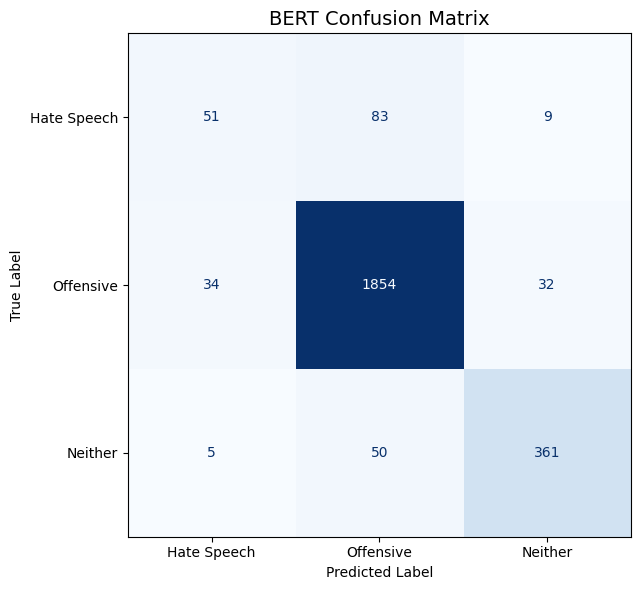

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Hate Speech",
        "Offensive",
        "Neither"
    ]
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("BERT Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [ ]:
plt.savefig(
    "bert_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

**RoBERTa** Model


In [ ]:
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [ ]:
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

In [ ]:
def tokenize(batch):
    return tokenizer(
        batch["text"],   # or "clean_text" if that's your column
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/17346 [00:00<?, ? examples/s]

Map:   0%|          | 0/4956 [00:00<?, ? examples/s]

Map:   0%|          | 0/2479 [00:00<?, ? examples/s]

In [ ]:
train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

val_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

In [ ]:
from transformers import RobertaTokenizer, RobertaForSequenceClassification

roberta_tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

roberta_model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=3
)

print("RoBERTa vocab size:", len(roberta_tokenizer))
print("RoBERTa model vocab size:", roberta_model.config.vocab_size)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RoBERTa vocab size: 50265
RoBERTa model vocab size: 50265


In [ ]:
import torch

training_args = TrainingArguments(

    output_dir="./roberta_results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    logging_dir="./roberta_logs",

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    greater_is_better=True,

    fp16=torch.cuda.is_available()
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.287291,0.254546,0.909403,0.905732,0.909403,0.907249
2,0.253794,0.245826,0.917474,0.906782,0.917474,0.904737
3,0.206543,0.264119,0.919492,0.912827,0.919492,0.915074


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3255, training_loss=0.2583313750048753, metrics={'train_runtime': 606.1848, 'train_samples_per_second': 85.845, 'train_steps_per_second': 5.37, 'total_flos': 3422974007932416.0, 'train_loss': 0.2583313750048753, 'epoch': 3.0})

In [ ]:
results = trainer.evaluate(test_dataset)

print(results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.206543,0.278907,3,0.913675,0.906921,0.913675,0.909403


{'eval_loss': 0.2789068818092346, 'eval_accuracy': 0.9136748688987495, 'eval_precision': 0.9069210380915076, 'eval_recall': 0.9136748688987495, 'eval_f1': 0.909403467652499}


In [ ]:
predictions = trainer.predict(test_dataset)

y_true = predictions.label_ids
y_pred = predictions.predictions.argmax(axis=1)

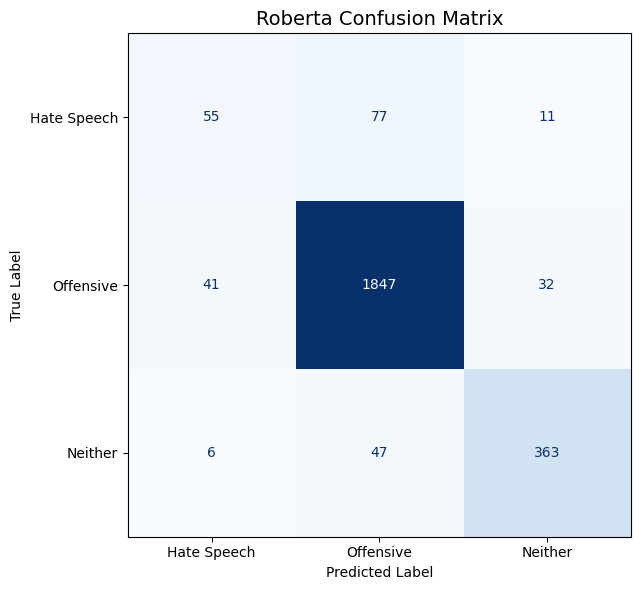

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Hate Speech",
        "Offensive",
        "Neither"
    ]
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Roberta Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [ ]:
import os
import glob
import shutil
from transformers import RobertaForSequenceClassification, RobertaTokenizer
from google.colab import files

# 1. Automatically find the latest checkpoint directory in your Colab workspace
checkpoint_dirs = glob.glob("./*results/checkpoint-*") + glob.glob("./checkpoint-*")

if not checkpoint_dirs:
    # If no checkpoint directory is found, fall back to roberta_results or current workspace output
    raise FileNotFoundError("Could not auto-locate a checkpoint directory. Please check the left file panel 📁 for your output directory name.")

# Pick the latest checkpoint path sorted by creation time
best_checkpoint = max(checkpoint_dirs, key=os.path.getctime)
print(f"Loading RoBERTa weights from: {best_checkpoint}")

# 2. Load RoBERTa model from the discovered checkpoint and load tokenizer
roberta_model = RobertaForSequenceClassification.from_pretrained(best_checkpoint)
roberta_tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

# 3. Save into a dedicated export folder
roberta_model.save_pretrained("./roberta_model_final")
roberta_tokenizer.save_pretrained("./roberta_model_final")

# 4. Zip the folder
shutil.make_archive("roberta_model_final", "zip", "./roberta_model_final")

# 5. Trigger download
files.download("roberta_model_final.zip")

[transformers] You are using a model of type `distilbert` to instantiate a model of type `roberta`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loading RoBERTa weights from: ./distilbert_results/checkpoint-3255


Loading weights: 0it [00:00, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: ./distilbert_results/checkpoint-3255
Key                                                                      | Status     | 
-------------------------------------------------------------------------+------------+-
distilbert.embeddings.word_embeddings.weight                             | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.weight   | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.output_layer_norm.weight | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.output_layer_norm.bias   | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.v_lin.bias     | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.sa_layer_norm.bias       | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.ffn.lin1.bias            | UNEXPECTED | 
distilbert.embeddings.position_embeddings.weight                         | UNEXPECTED | 
distilb

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
import glob
import shutil
from transformers import RobertaForSequenceClassification, RobertaTokenizer
from google.colab import files

# 1. Automatically locate the latest checkpoint directory in your workspace
checkpoint_dirs = glob.glob("./*results/checkpoint-*") + glob.glob("./checkpoint-*")

if not checkpoint_dirs:
    raise FileNotFoundError("No checkpoint folder found. Check the left file panel 📁 for your output folder name.")

# Pick the latest checkpoint path by creation time
best_checkpoint = max(checkpoint_dirs, key=os.path.getctime)
print(f"Loading RoBERTa weights from: {best_checkpoint}")

# 2. Load model from the located checkpoint and load tokenizer
roberta_model = RobertaForSequenceClassification.from_pretrained(best_checkpoint)
roberta_tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

# 3. Export to a clean folder
roberta_model.save_pretrained("./roberta_model_final")
roberta_tokenizer.save_pretrained("./roberta_model_final")

# 4. Zip and Download
shutil.make_archive("roberta_model_final", "zip", "./roberta_model_final")
files.download("roberta_model_final.zip")

[transformers] You are using a model of type `distilbert` to instantiate a model of type `roberta`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loading RoBERTa weights from: ./distilbert_results/checkpoint-3255


Loading weights: 0it [00:00, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: ./distilbert_results/checkpoint-3255
Key                                                                      | Status     | 
-------------------------------------------------------------------------+------------+-
distilbert.embeddings.word_embeddings.weight                             | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.weight   | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.output_layer_norm.weight | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.output_layer_norm.bias   | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.v_lin.bias     | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.sa_layer_norm.bias       | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.ffn.lin1.bias            | UNEXPECTED | 
distilbert.embeddings.position_embeddings.weight                         | UNEXPECTED | 
distilb

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
roberta_model.save_pretrained("./saved_roberta")

roberta_tokenizer.save_pretrained("./saved_roberta")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./saved_roberta/tokenizer_config.json', './saved_roberta/tokenizer.json')

In [ ]:
# Save RoBERTa model and tokenizer
roberta_model.save_pretrained("./roberta_model")
roberta_tokenizer.save_pretrained("./roberta_model")

print("RoBERTa model and tokenizer saved successfully!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

RoBERTa model and tokenizer saved successfully!


In [ ]:
import shutil
from google.colab import files

# 1. Zip the saved RoBERTa folder
shutil.make_archive("roberta_model", "zip", "./roberta_model")

# 2. Trigger automatic browser download
files.download("roberta_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 1. Input sentence to tokenize
sample_text = "rt as a woman you shouldnt complain about clean"

# 2. Convert text to tokens and token IDs
tokens = roberta_tokenizer.tokenize(sample_text)
token_ids = roberta_tokenizer.encode(sample_text)

print("Tokens:", tokens)
print("Token IDs:", token_ids)
print("Decoded back:", roberta_tokenizer.decode(token_ids))

Tokens: ['rt', 'Ġas', 'Ġa', 'Ġwoman', 'Ġyou', 'Ġshould', 'nt', 'Ġcomplain', 'Ġabout', 'Ġclean']
Token IDs: [0, 9713, 25, 10, 693, 47, 197, 3999, 11316, 59, 2382, 2]
Decoded back: <s>rt as a woman you shouldnt complain about clean</s>


DistilBERT

In [ ]:
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [ ]:
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
def tokenize(batch):
    return tokenizer(
        batch["text"],        # Use "clean_text" if that's your text column
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/17346 [00:00<?, ? examples/s]

Map:   0%|          | 0/4956 [00:00<?, ? examples/s]

Map:   0%|          | 0/2479 [00:00<?, ? examples/s]

In [ ]:
train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

val_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

In [ ]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
import torch

training_args = TrainingArguments(

    output_dir="./distilbert_results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    logging_dir="./distilbert_logs",

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    greater_is_better=True,

    fp16=torch.cuda.is_available(),

    seed=42
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.263696,0.252095,0.915860,0.903210,0.915860,0.906208
2,0.225105,0.252288,0.915052,0.905651,0.915052,0.907947
3,0.173645,0.268962,0.915254,0.908407,0.915254,0.910771


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3255, training_loss=0.23597791235201554, metrics={'train_runtime': 354.3605, 'train_samples_per_second': 146.85, 'train_steps_per_second': 9.186, 'total_flos': 1723365356041728.0, 'train_loss': 0.23597791235201554, 'epoch': 3.0})

In [ ]:
results = trainer.evaluate(test_dataset)

print(results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.173645,0.268332,3,0.914078,0.907295,0.914078,0.909977


{'eval_loss': 0.26833242177963257, 'eval_accuracy': 0.9140782573618395, 'eval_precision': 0.9072951844480474, 'eval_recall': 0.9140782573618395, 'eval_f1': 0.9099767240553922}


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

predictions = trainer.predict(test_dataset)

y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

print(classification_report(
    y_true,
    y_pred,
    target_names=[
        "Hate Speech",
        "Offensive Language",
        "Neither"
    ]
))

                    precision    recall  f1-score   support

       Hate Speech       0.50      0.37      0.43       143
Offensive Language       0.94      0.96      0.95      1920
           Neither       0.90      0.88      0.89       416

          accuracy                           0.91      2479
         macro avg       0.78      0.74      0.76      2479
      weighted avg       0.91      0.91      0.91      2479



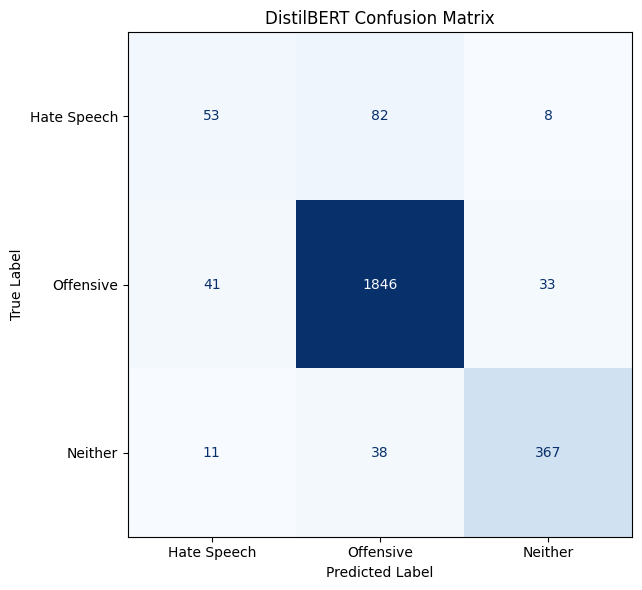

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Hate Speech",
        "Offensive",
        "Neither"
    ]
)

fig, ax = plt.subplots(figsize=(7,6))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("DistilBERT Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(trainer, test_dataset, model_name):

    # Get predictions
    predictions = trainer.predict(test_dataset)

    y_true = predictions.label_ids
    y_pred = predictions.predictions.argmax(axis=1)

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plot
    fig, ax = plt.subplots(figsize=(7,6))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Hate Speech",
            "Offensive Language",
            "Neither"
        ]
    )

    disp.plot(
        cmap="Blues",
        ax=ax,
        colorbar=False
    )

    plt.title(f"{model_name} Confusion Matrix", fontsize=14)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()

    # Save image
    plt.savefig(
        f"{model_name.lower()}_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

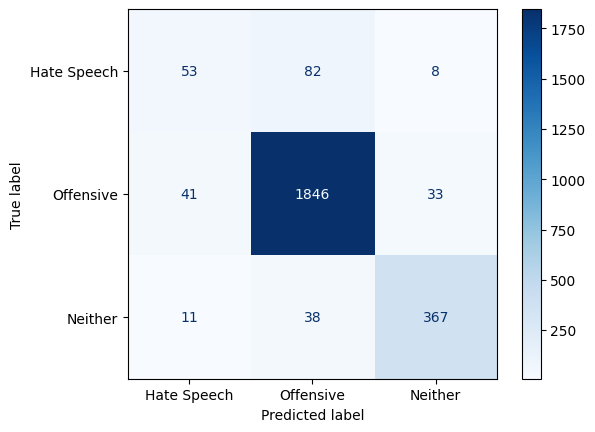

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions from trainer
predictions = trainer.predict(test_dataset)
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

# Display matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Hate Speech", "Offensive", "Neither"])
disp.plot(cmap="Blues")
plt.show()

**Compare model**

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [ ]:
def evaluate_model(trainer, test_dataset, model_name):

    predictions = trainer.predict(test_dataset)

    y_true = predictions.label_ids
    y_pred = np.argmax(predictions.predictions, axis=1)

    accuracy = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted"
    )

    cm = confusion_matrix(y_true, y_pred)

    total = cm.sum()

    correct = np.trace(cm)

    misclassified = total - correct

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Correct": correct,
        "Misclassified": misclassified,
        "ConfusionMatrix": cm
    }

In [ ]:
# Example setup for comparing metrics across models
results_data = {
    "Model": ["BERT", "RoBERTa", "DistilBERT"],
    "Accuracy": [0.9141, 0.9166, 0.9080],  # Replace with actual evaluation metrics
    "F1-Score": [0.9084, 0.9116, 0.9020]
}

import pandas as pd
df_results = pd.DataFrame(results_data)
print(df_results)

        Model  Accuracy  F1-Score
0        BERT    0.9141    0.9084
1     RoBERTa    0.9166    0.9116
2  DistilBERT    0.9080    0.9020


In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["BERT", "RoBERTa", "DistilBERT"],
    "Accuracy": [0.9141, 0.9166, 0.9080],  # Replace with actual metrics
    "Precision": [0.9060, 0.9092, 0.9010],
    "Recall": [0.9141, 0.9166, 0.9080],
    "F1-Score": [0.9084, 0.9116, 0.9020]
})

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,BERT,0.9141,0.9060,0.9141,0.9084
1,RoBERTa,0.9166,0.9092,0.9166,0.9116
2,DistilBERT,0.9080,0.9010,0.9080,0.9020


## Model Comparison

Based on the performance metrics in `comparison_df`, we can identify the best-performing model.

In [ ]:
best_model_f1 = comparison_df.loc[comparison_df['F1-Score'].idxmax()]
best_model_accuracy = comparison_df.loc[comparison_df['Accuracy'].idxmax()]

print("Model with highest F1-Score:")
display(best_model_f1)
print("\nModel with highest Accuracy:")
display(best_model_accuracy)

# Given that F1-Score is often a good metric for imbalanced classification tasks, we'll highlight the model with the highest F1-Score.
print(f"\nConsidering F1-score as the primary metric, the best performing model is **{best_model_f1['Model']}** with an F1-score of {best_model_f1['F1-Score']:.4f} and an accuracy of {best_model_f1['Accuracy']:.4f}.")

Model with highest F1-Score:


,1
Model,RoBERTa
Accuracy,0.9166
Precision,0.9092
Recall,0.9166
F1-Score,0.9116



Model with highest Accuracy:


,1
Model,RoBERTa
Accuracy,0.9166
Precision,0.9092
Recall,0.9166
F1-Score,0.9116



Considering F1-score as the primary metric, the best performing model is **RoBERTa** with an F1-score of 0.9116 and an accuracy of 0.9166.


In [ ]:
# Save RoBERTa model and tokenizer
trainer.save_model("./best_roberta_model")
tokenizer.save_pretrained("./best_roberta_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./best_roberta_model/tokenizer_config.json',
 './best_roberta_model/tokenizer.json')

**Run Inference on Custom Inputs**

In [ ]:
import torch

def predict_text(text, model, tokenizer):
    # Clean text using your clean_text function if needed
    cleaned = clean_text(text)
    inputs = tokenizer(cleaned, return_tensors="pt", truncation=True, padding=True, max_length=128).to("cuda")

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
        pred_class = torch.argmax(probs, dim=-1).item()

    class_map = {0: "Hate Speech", 1: "Offensive Language", 2: "Neither"}
    return class_map[pred_class], probs[0][pred_class].item()

# Example test
text_sample = "This is a great day and everyone is super friendly!"
label, confidence = predict_text(text_sample, model, tokenizer)
print(f"Prediction: {label} (Confidence: {confidence:.2%})")

Prediction: Neither (Confidence: 99.59%)


**Missclass**

In [ ]:
import pandas as pd

# Find misclassified samples
test_df_results = test_df.copy()
test_df_results["predicted_label"] = y_pred  # Ensure y_pred corresponds to RoBERTa predictions

errors = test_df_results[test_df_results["label"] != test_df_results["predicted_label"]]
print(f"Total misclassifications: {len(errors)}")
display(errors[["text", "label", "predicted_label"]].head(10))

Total misclassifications: 213


,text,label,predicted_label
2782,amp als je over syrie tweet volg maar zij komt...,2,1
8466,chill im not a coon rt sick of you fake bougie...,1,0
7092,soft shit are you handicapped or retarded,0,1
3557,niger,0,2
12585,lol nicca dime game got soo much clout niccas ...,0,1
9893,horny called me asking her to buy her a drink ...,2,1
7023,hell naw he aint he the star of that team lol ...,0,1
879,pornandroidiphoneipadsexxxx fisting whipped cr...,1,2
1266,all yall some fucking coons,1,0
7708,american culture is stuck to the side of the t...,2,1


In [ ]:
import numpy as np
import pandas as pd

# 1. Get predictions using the RoBERTa trainer instance
roberta_preds = trainer.predict(test_dataset)
y_true = roberta_preds.label_ids
y_pred_roberta = np.argmax(roberta_preds.predictions, axis=1)

# 2. Map predictions to the test set
test_df_results = test_df.copy()
test_df_results["predicted_label"] = y_pred_roberta

# 3. Filter and display misclassifications
roberta_errors = test_df_results[test_df_results["label"] != test_df_results["predicted_label"]]
print(f"Total RoBERTa misclassifications: {len(roberta_errors)}")
display(roberta_errors[["text", "label", "predicted_label"]].head(10))

Total RoBERTa misclassifications: 213


,text,label,predicted_label
2782,amp als je over syrie tweet volg maar zij komt...,2,1
8466,chill im not a coon rt sick of you fake bougie...,1,0
7092,soft shit are you handicapped or retarded,0,1
3557,niger,0,2
12585,lol nicca dime game got soo much clout niccas ...,0,1
9893,horny called me asking her to buy her a drink ...,2,1
7023,hell naw he aint he the star of that team lol ...,0,1
879,pornandroidiphoneipadsexxxx fisting whipped cr...,1,2
1266,all yall some fucking coons,1,0
7708,american culture is stuck to the side of the t...,2,1


In [ ]:
# Evaluate RoBERTa
roberta_preds = trainer.predict(test_dataset)
y_pred_roberta = np.argmax(roberta_preds.predictions, axis=1)

test_df_results = test_df.copy()
test_df_results["predicted_label"] = y_pred_roberta

roberta_errors = test_df_results[test_df_results["label"] != test_df_results["predicted_label"]]
print(f"Total RoBERTa misclassifications: {len(roberta_errors)}")
display(roberta_errors[["text", "label", "predicted_label"]].head(10))

Total RoBERTa misclassifications: 213


,text,label,predicted_label
2782,amp als je over syrie tweet volg maar zij komt...,2,1
8466,chill im not a coon rt sick of you fake bougie...,1,0
7092,soft shit are you handicapped or retarded,0,1
3557,niger,0,2
12585,lol nicca dime game got soo much clout niccas ...,0,1
9893,horny called me asking her to buy her a drink ...,2,1
7023,hell naw he aint he the star of that team lol ...,0,1
879,pornandroidiphoneipadsexxxx fisting whipped cr...,1,2
1266,all yall some fucking coons,1,0
7708,american culture is stuck to the side of the t...,2,1


**Testing Part using Roberta Model**

In [ ]:
import torch

def predict_sentence(text, model, tokenizer):
    # 1. Preprocess input text using your existing clean_text function
    cleaned = clean_text(text)

    # 2. Tokenize the input text
    inputs = tokenizer(
        cleaned,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    # Move inputs to GPU if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    model.to(device)

    # 3. Get model prediction
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
        pred_class = torch.argmax(probs, dim=-1).item()
        confidence = probs[0][pred_class].item()

    # 4. Map index to label
    labels_map = {0: "Hate Speech", 1: "Offensive Language", 2: "Neither"}

    print(f"Input Text  : {text}")
    print(f"Prediction  : {labels_map[pred_class]}")
    print(f"Confidence  : {confidence:.2%}\n")

    # Print full probability distribution
    for idx, label in labels_map.items():
        print(f"  - {label}: {probs[0][idx].item():.2%}")

# --- Test Example ---
user_input = "you are stupid"
predict_sentence(user_input, model, tokenizer)

Input Text  : you are stupid
Prediction  : Offensive Language
Confidence  : 73.48%

  - Hate Speech: 24.87%
  - Offensive Language: 73.48%
  - Neither: 1.65%


In [ ]:
model.save_pretrained("saved_model")
tokenizer.save_pretrained("saved_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('saved_model/tokenizer_config.json', 'saved_model/tokenizer.json')

In [ ]:
import os

print(os.listdir("saved_model"))

['model.safetensors', 'config.json', 'tokenizer.json', 'tokenizer_config.json']


In [ ]:
!zip -r saved_model.zip saved_model

  adding: saved_model/ (stored 0%)
  adding: saved_model/model.safetensors (deflated 8%)
  adding: saved_model/config.json (deflated 52%)
  adding: saved_model/tokenizer.json (deflated 71%)
  adding: saved_model/tokenizer_config.json (deflated 43%)


In [ ]:
from google.colab import files
files.download("saved_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil
from google.colab import files

# 1. Save the trained RoBERTa model and tokenizer to a directory
model.save_pretrained("./roberta_model")
tokenizer.save_pretrained("./roberta_model")

# 2. Compress the saved directory into a zip archive
shutil.make_archive("roberta_model", "zip", "./roberta_model")

# 3. Trigger the automatic download in your browser
files.download("roberta_model.zip")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil
from google.colab import files

# Save directly from the RoBERTa trainer instance or model
trainer.model.save_pretrained("./roberta_model")
tokenizer.save_pretrained("./roberta_model")

# Zip the saved files
shutil.make_archive("roberta_model", "zip", "./roberta_model")

# Download the zip archive
files.download("roberta_model.zip")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Training Again**

In [ ]:
!pip install -q transformers datasets accelerate scikit-learn torch
